# Census Income Prediction

**Dataset:** UCI Adult (1994 Census). **Task:** Predict income (≤50K vs >50K).

**Notebook flow:** 1. Data Loading → 2. EDA → 3. Encoding (RQ1) → 4. Model Training → 5. Optimisation → 6. Explainability (RQ2) → 7. Fairness (RQ3) → 8. Final Evaluation → 9. Conclusions → 10. Academic Declaration.

**1. Data Loading and Overview**

- Load dataset (train + test)
- Show shape, columns, missing values
- Identify categorical, numerical, and sensitive features

In [245]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [246]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

try:
    import xgboost as xgb
except ImportError:
    xgb = None
try:
    import shap
except ImportError:
    shap = None

**Load data and show overview**

In [247]:
# Define column names based on UCI Adult Dataset documentation
column_names = [
    'age',                # Continuous: Age of the individual
    'workclass',          # Categorical: Type of employment
    'fnlwgt',             # Continuous: Final weight (Census sampling weight)
    'education',          # Categorical: Highest education level (HIGH CARDINALITY)
    'education-num',      # Continuous: Education in numerical form
    'marital-status',     # Categorical: Marital status
    'occupation',         # Categorical: Type of occupation (HIGH CARDINALITY)
    'relationship',       # Categorical: Relationship status
    'race',               # Categorical: Race (SENSITIVE FEATURE)
    'sex',                # Categorical: Gender (SENSITIVE FEATURE)
    'capital-gain',       # Continuous: Capital gains
    'capital-loss',       # Continuous: Capital losses
    'hours-per-week',     # Continuous: Hours worked per week
    'native-country',     # Categorical: Country of origin (HIGH CARDINALITY)
    'income'              # Target: Income level (<=50K or >50K)
]

print("Column names defined:")
print(f"Total features: {len(column_names) - 1}")
print(f"Target variable: income")

Column names defined:
Total features: 14
Target variable: income


In [248]:
# Load training data (path relative to current working directory; run from "2. Coding part")
train_data_path = os.path.join(os.getcwd(), 'adult', 'adult.data')

# Read the data (no header in original file)
df_train = pd.read_csv(
    train_data_path,
    names=column_names,
    sep=',\s*',           # Handle comma + space separator
    engine='python',      # Use python engine for regex separator
    na_values='?'         # '?' represents missing values
)

print("✓ Training data loaded successfully")
print(f"\nTraining set shape: {df_train.shape}")
print(f"  - Rows (samples): {df_train.shape[0]:,}")
print(f"  - Columns (features + target): {df_train.shape[1]}")

✓ Training data loaded successfully

Training set shape: (32561, 15)
  - Rows (samples): 32,561
  - Columns (features + target): 15


In [249]:
# Load test data (path relative to current working directory)
test_data_path = os.path.join(os.getcwd(), 'adult', 'adult.test')

# Read test data (first line is a comment, skip it)
df_test = pd.read_csv(
    test_data_path,
    names=column_names,
    sep=',\s*',
    engine='python',
    na_values='?',
    skiprows=1            # Skip the first comment line
)

# Clean the income column (test set has '.' at the end)
df_test['income'] = df_test['income'].str.replace('.', '', regex=False)

print("✓ Test data loaded successfully")
print(f"\nTest set shape: {df_test.shape}")
print(f"  - Rows (samples): {df_test.shape[0]:,}")
print(f"  - Columns (features + target): {df_test.shape[1]}")

✓ Test data loaded successfully

Test set shape: (16281, 15)
  - Rows (samples): 16,281
  - Columns (features + target): 15


In [250]:
# Display first few rows of training data
print("First 5 rows of the training dataset:\n")
df_train.head()

First 5 rows of the training dataset:



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [251]:
# Display data types and basic information
print("Dataset Information:\n")
df_train.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [252]:
# Statistical summary of numerical features
print("Statistical Summary of Numerical Features:\n")
df_train.describe()

Statistical Summary of Numerical Features:



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Clean data and define feature types** (categorical, numerical, high-cardinality, sensitive)

In [253]:
# Check for missing values in training data
print("Missing Values in Training Data:\n")
missing_train = df_train.isnull().sum()
missing_train_pct = (missing_train / len(df_train)) * 100

# Create a summary dataframe
missing_summary_train = pd.DataFrame({
    'Missing Count': missing_train,
    'Percentage': missing_train_pct
})

# Show only columns with missing values
missing_summary_train = missing_summary_train[missing_summary_train['Missing Count'] > 0]
missing_summary_train = missing_summary_train.sort_values('Missing Count', ascending=False)

if len(missing_summary_train) > 0:
    print(missing_summary_train)
else:
    print("No missing values found!")

Missing Values in Training Data:

                Missing Count  Percentage
occupation               1843    5.660146
workclass                1836    5.638647
native-country            583    1.790486


In [254]:
# Check for missing values in test data
print("Missing Values in Test Data:\n")
missing_test = df_test.isnull().sum()
missing_test_pct = (missing_test / len(df_test)) * 100

missing_summary_test = pd.DataFrame({
    'Missing Count': missing_test,
    'Percentage': missing_test_pct
})

missing_summary_test = missing_summary_test[missing_summary_test['Missing Count'] > 0]
missing_summary_test = missing_summary_test.sort_values('Missing Count', ascending=False)

if len(missing_summary_test) > 0:
    print(missing_summary_test)
else:
    print("No missing values found!")

Missing Values in Test Data:

                Missing Count  Percentage
occupation                966    5.933296
workclass                 963    5.914870
native-country            274    1.682943


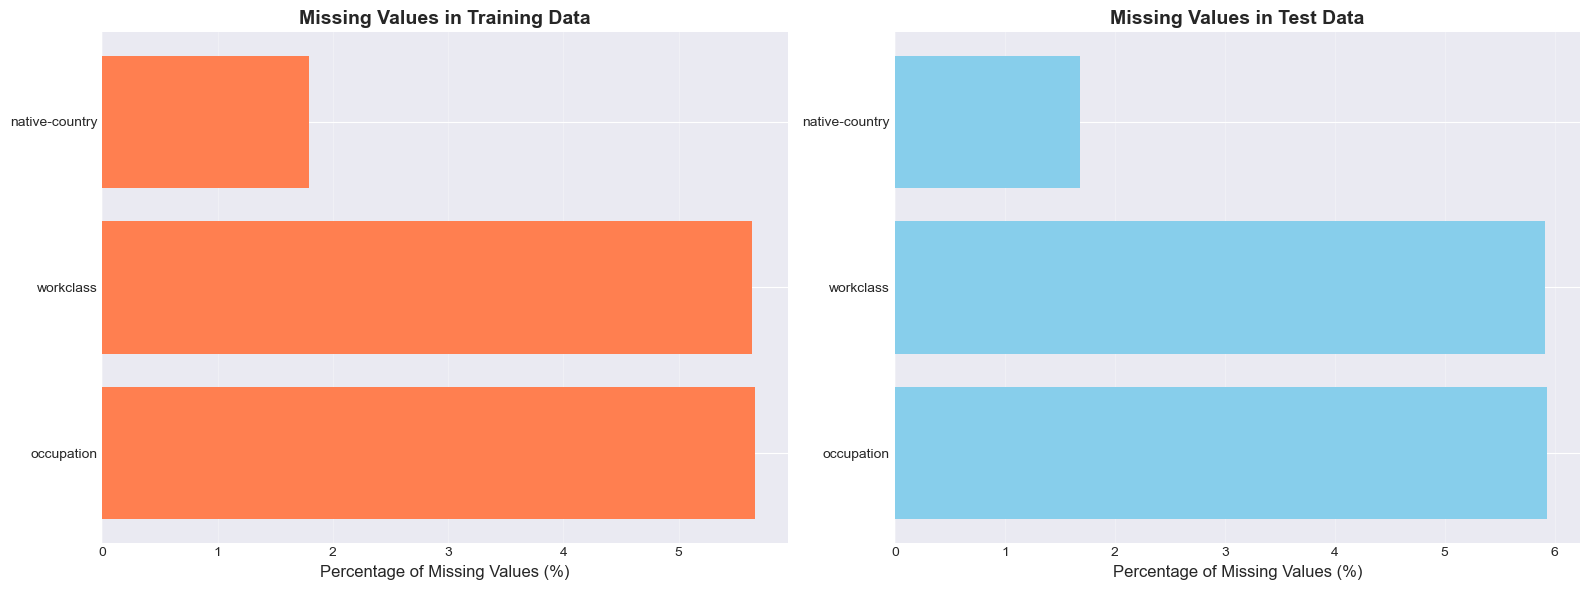


✓ Missing values visualized


In [255]:
# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training data missing values
if len(missing_summary_train) > 0:
    axes[0].barh(missing_summary_train.index, missing_summary_train['Percentage'], color='coral')
    axes[0].set_xlabel('Percentage of Missing Values (%)', fontsize=12)
    axes[0].set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Training Data', fontsize=14, fontweight='bold')

# Test data missing values
if len(missing_summary_test) > 0:
    axes[1].barh(missing_summary_test.index, missing_summary_test['Percentage'], color='skyblue')
    axes[1].set_xlabel('Percentage of Missing Values (%)', fontsize=12)
    axes[1].set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', fontsize=14)
    axes[1].set_title('Missing Values in Test Data', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Missing values visualized")

In [256]:
# Handle missing values by removing rows with missing data
# (Alternative: Could use mode imputation for categorical variables)

print(f"Before removing missing values:")
print(f"  Training: {len(df_train):,} rows")
print(f"  Test: {len(df_test):,} rows")

# Remove missing values
df_train_clean = df_train.dropna()
df_test_clean = df_test.dropna()

print(f"\nAfter removing missing values:")
print(f"  Training: {len(df_train_clean):,} rows (removed {len(df_train) - len(df_train_clean):,})")
print(f"  Test: {len(df_test_clean):,} rows (removed {len(df_test) - len(df_test_clean):,})")

print("\n✓ Missing values handled")

Before removing missing values:
  Training: 32,561 rows
  Test: 16,281 rows

After removing missing values:
  Training: 30,162 rows (removed 2,399)
  Test: 15,060 rows (removed 1,221)

✓ Missing values handled


In [257]:
# Identify feature types
numerical_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Identify high-cardinality categorical features (for RQ1)
high_cardinality_features = ['education', 'occupation', 'native-country']

# Identify sensitive features (for RQ3)
sensitive_features = ['sex', 'race']

print("Feature Classification:\n")
print(f"Numerical features ({len(numerical_features)}):")
print(f"  {', '.join(numerical_features)}\n")

print(f"Categorical features ({len(categorical_features)}):")
print(f"  {', '.join(categorical_features)}\n")

print(f"High-cardinality features ({len(high_cardinality_features)}):")
print(f"  {', '.join(high_cardinality_features)}")
print(f"  (These will be analyzed in RQ1)\n")

print(f"Sensitive features ({len(sensitive_features)}):")
print(f"  {', '.join(sensitive_features)}")
print(f"  (These will be excluded in RQ3 fairness analysis)")

Feature Classification:

Numerical features (6):
  age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week

Categorical features (8):
  workclass, education, marital-status, occupation, relationship, race, sex, native-country

High-cardinality features (3):
  education, occupation, native-country
  (These will be analyzed in RQ1)

Sensitive features (2):
  sex, race
  (These will be excluded in RQ3 fairness analysis)


In [258]:
# Check cardinality of categorical features
print("Cardinality of Categorical Features:\n")

cardinality_info = []
for feature in categorical_features:
    unique_count = df_train_clean[feature].nunique()
    cardinality_info.append({
        'Feature': feature,
        'Unique Values': unique_count,
        'High Cardinality': 'Yes' if feature in high_cardinality_features else 'No',
        'Sensitive': 'Yes' if feature in sensitive_features else 'No'
    })

cardinality_df = pd.DataFrame(cardinality_info)
cardinality_df = cardinality_df.sort_values('Unique Values', ascending=False)
cardinality_df

Cardinality of Categorical Features:



,Feature,Unique Values,High Cardinality,Sensitive
7,native-country,41,Yes,No
1,education,16,Yes,No
3,occupation,14,Yes,No
0,workclass,7,No,No
2,marital-status,7,No,No
4,relationship,6,No,No
5,race,5,No,Yes
6,sex,2,No,Yes


**2. Exploratory Data Analysis**

- Class distribution (income)
- Key feature distributions
- Short insights (2–3 bullets below)

**Target (income) distribution**

Target (income) distribution:
 income
<=50K    22654
>50K      7508
Name: count, dtype: int64

Share: income
<=50K    0.751
>50K     0.249

Class imbalance ratio: 3.02:1 → use stratified sampling.


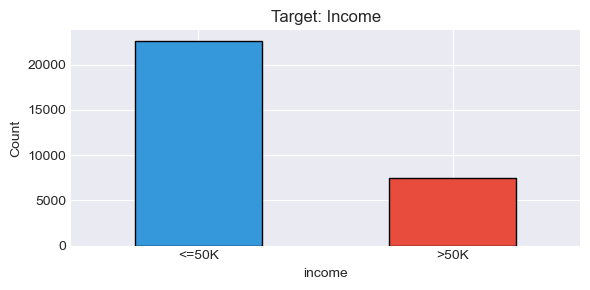

In [259]:
# Target distribution and class imbalance (drives stratification in CV and metrics)
target_counts = df_train_clean['income'].value_counts()
print("Target (income) distribution:\n", target_counts)
print("\nShare:", (target_counts / len(df_train_clean)).round(3).to_string())
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1 → use stratified sampling.")
fig, ax = plt.subplots(figsize=(6, 3))
target_counts.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black')
ax.set_title('Target: Income'); ax.set_ylabel('Count'); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

**Relationship with target**
- Correlation of numerical features with income (below); key for encoding and model choice.

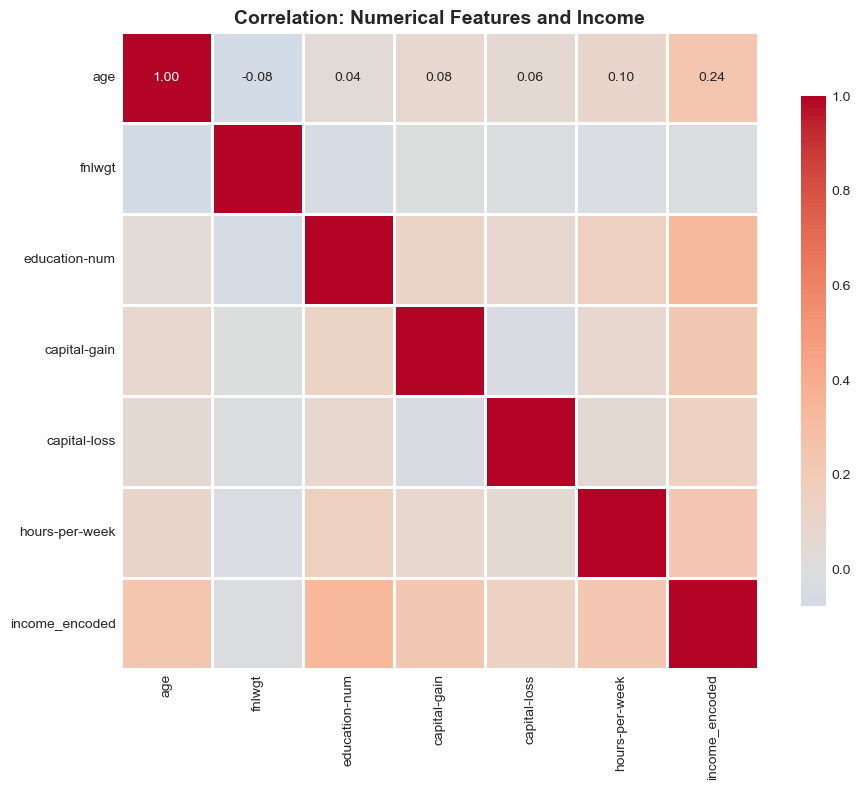

Correlations with income (sorted):
  education-num       : +0.3353
  age                 : +0.2420
  hours-per-week      : +0.2295
  capital-gain        : +0.2212
  capital-loss        : +0.1501
  fnlwgt              : -0.0090


In [260]:
# Correlation with income (drives feature importance and RQ context)
df_corr = df_train_clean.copy()
df_corr['income_encoded'] = (df_corr['income'] == '>50K').astype(int)
correlation_matrix = df_corr[numerical_features + ['income_encoded']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation: Numerical Features and Income', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("Correlations with income (sorted):")
for f, v in correlation_matrix['income_encoded'].drop('income_encoded').sort_values(key=abs, ascending=False).items():
    print(f"  {f:20s}: {v:+.4f}")

**EDA insights**
- Class imbalance: more ≤50K than >50K; stratification used where needed.
- Education, occupation, age, and hours-per-week are strongly associated with income.
- Sensitive attributes (sex, race) are present; we compare models with and without them in RQ3.

**3. Encoding Strategy (RQ1)**

- High-cardinality categorical features identified
- Apply: One-Hot, Ordinal (Label), Frequency encoding
- Target encoding: can cause leakage if not fit per fold; here we fit on train only and evaluate on holdout
- Stratified 5-fold CV with Logistic Regression
- Comparison table: Accuracy | F1 | ROC-AUC | Number of Features

In [267]:
# RQ1 Step 1: Prepare data + evaluation helper
X_train = df_train_clean.drop('income', axis=1)
y_train = (df_train_clean['income'] == '>50K').astype(int)
X_test = df_test_clean.drop('income', axis=1)
y_test = (df_test_clean['income'] == '>50K').astype(int)

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred_te = model.predict(X_te)
    metrics = {'Model': name, 'Test Accuracy': accuracy_score(y_te, y_pred_te),
               'F1-Score': f1_score(y_te, y_pred_te), 'Precision': precision_score(y_te, y_pred_te),
               'Recall': recall_score(y_te, y_pred_te)}
    if hasattr(model, 'predict_proba'):
        metrics['AUC-ROC'] = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    else:
        metrics['AUC-ROC'] = np.nan
    return metrics

all_results = []

**Ordinal (Label) encoding + models**

In [268]:
X_train_le = X_train.copy()
X_test_le = X_test.copy()
for feat in categorical_features:
    le = LabelEncoder()
    X_train_le[feat] = le.fit_transform(X_train_le[feat].astype(str))
    X_test_le[feat] = X_test_le[feat].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

scaler_le = StandardScaler()
X_train_le_final = scaler_le.fit_transform(X_train_le.values.astype(np.float64))
X_test_le_final = scaler_le.transform(X_test_le.values.astype(np.float64))

lr_le = LogisticRegression(max_iter=1000, random_state=42)
results_lr_le = evaluate_model(lr_le, X_train_le_final, y_train, X_test_le_final, y_test, "Logistic Regression (LE)")
results_lr_le['Encoding'] = 'Label'
all_results.append(results_lr_le)

rf_le = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf_le = evaluate_model(rf_le, X_train_le_final, y_train, X_test_le_final, y_test, "Random Forest (LE)")
results_rf_le['Encoding'] = 'Label'
all_results.append(results_rf_le)

if xgb is not None:
    xgb_le = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
    results_xgb_le = evaluate_model(xgb_le, X_train_le_final, y_train, X_test_le_final, y_test, "XGBoost (LE)")
    results_xgb_le['Encoding'] = 'Label'
    all_results.append(results_xgb_le)

**Target encoding** (smoothed). Note: can cause leakage if not fit inside CV; here fit on train only, evaluate on holdout.

In [269]:
# Target encoding: fit on train, apply to train and test (smoothed to avoid overfitting)
X_train_te = X_train.copy()
X_test_te = X_test.copy()
smoothing = 10
global_mean = y_train.mean()

for col in categorical_features:
    train_df = pd.DataFrame({'y': y_train, 'cat': X_train[col].astype(str)})
    agg = train_df.groupby('cat')['y'].agg(['mean', 'count'])
    enc = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)
    X_train_te[col] = X_train_te[col].astype(str).map(enc).fillna(global_mean)
    X_test_te[col] = X_test_te[col].astype(str).map(enc).fillna(global_mean)

scaler_te = StandardScaler()
X_train_te_final = scaler_te.fit_transform(X_train_te.values.astype(np.float64))
X_test_te_final = scaler_te.transform(X_test_te.values.astype(np.float64))

lr_te = LogisticRegression(max_iter=1000, random_state=42)
results_lr_te = evaluate_model(lr_te, X_train_te_final, y_train, X_test_te_final, y_test, "Logistic Regression (TE)")
results_lr_te['Encoding'] = 'Target'
all_results.append(results_lr_te)

rf_te = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf_te = evaluate_model(rf_te, X_train_te_final, y_train, X_test_te_final, y_test, "Random Forest (TE)")
results_rf_te['Encoding'] = 'Target'
all_results.append(results_rf_te)

if xgb is not None:
    xgb_te = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
    results_xgb_te = evaluate_model(xgb_te, X_train_te_final, y_train, X_test_te_final, y_test, "XGBoost (TE)")
    results_xgb_te['Encoding'] = 'Target'
    all_results.append(results_xgb_te)

**Frequency encoding** (category → count in train)

In [270]:
# Frequency encoding: category -> count in train
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

for col in categorical_features:
    counts = X_train[col].astype(str).value_counts()
    X_train_fe[col] = X_train_fe[col].astype(str).map(counts).fillna(0)
    X_test_fe[col] = X_test_fe[col].astype(str).map(counts).fillna(0)

scaler_fe = StandardScaler()
X_train_fe_final = scaler_fe.fit_transform(X_train_fe.values.astype(np.float64))
X_test_fe_final = scaler_fe.transform(X_test_fe.values.astype(np.float64))

lr_fe = LogisticRegression(max_iter=1000, random_state=42)
results_lr_fe = evaluate_model(lr_fe, X_train_fe_final, y_train, X_test_fe_final, y_test, "Logistic Regression (FE)")
results_lr_fe['Encoding'] = 'Frequency'
all_results.append(results_lr_fe)

rf_fe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf_fe = evaluate_model(rf_fe, X_train_fe_final, y_train, X_test_fe_final, y_test, "Random Forest (FE)")
results_rf_fe['Encoding'] = 'Frequency'
all_results.append(results_rf_fe)

if xgb is not None:
    xgb_fe = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
    results_xgb_fe = evaluate_model(xgb_fe, X_train_fe_final, y_train, X_test_fe_final, y_test, "XGBoost (FE)")
    results_xgb_fe['Encoding'] = 'Frequency'
    all_results.append(results_xgb_fe)

**One-Hot encoding + models**

In [271]:
encoder_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc_train = encoder_ohe.fit_transform(X_train[categorical_features])
enc_test = encoder_ohe.transform(X_test[categorical_features])
X_train_ohe_final = np.hstack([X_train[numerical_features].values, enc_train])
X_test_ohe_final = np.hstack([X_test[numerical_features].values, enc_test])

scaler_ohe = StandardScaler()
X_train_ohe_final[:, :len(numerical_features)] = scaler_ohe.fit_transform(X_train_ohe_final[:, :len(numerical_features)])
X_test_ohe_final[:, :len(numerical_features)] = scaler_ohe.transform(X_test_ohe_final[:, :len(numerical_features)])

lr_ohe = LogisticRegression(max_iter=1000, random_state=42)
results_lr_ohe = evaluate_model(lr_ohe, X_train_ohe_final, y_train, X_test_ohe_final, y_test, "Logistic Regression (OHE)")
results_lr_ohe['Encoding'] = 'One-Hot'
all_results.append(results_lr_ohe)

rf_ohe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
results_rf_ohe = evaluate_model(rf_ohe, X_train_ohe_final, y_train, X_test_ohe_final, y_test, "Random Forest (OHE)")
results_rf_ohe['Encoding'] = 'One-Hot'
all_results.append(results_rf_ohe)

if xgb is not None:
    xgb_ohe = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
    results_xgb_ohe = evaluate_model(xgb_ohe, X_train_ohe_final, y_train, X_test_ohe_final, y_test, "XGBoost (OHE)")
    results_xgb_ohe['Encoding'] = 'One-Hot'
    all_results.append(results_xgb_ohe)

**Encoding comparison table** (Accuracy | F1 | ROC-AUC | N features) and plot

,Model,Test Accuracy,F1-Score,Precision,Recall,AUC-ROC,Encoding
0,Logistic Regression (LE),0.820252,0.555720,0.707480,0.457568,0.848296,Label
1,Random Forest (LE),0.849602,0.667352,0.730782,0.614054,0.903298,Label
2,XGBoost (LE),0.865471,0.707056,0.760261,0.660811,0.924415,Label
3,Logistic Regression (TE),0.844157,0.649020,0.726481,0.586486,0.900801,Target
4,Random Forest (TE),0.850266,0.671235,0.728712,0.622162,0.904464,Target
5,XGBoost (TE),0.867131,0.709537,0.766384,0.660541,0.924755,Target
6,Logistic Regression (FE),0.834130,0.610296,0.721771,0.528649,0.882937,Frequency
7,Random Forest (FE),0.850133,0.671135,0.728106,0.622432,0.902945,Frequency
8,XGBoost (FE),0.864741,0.704225,0.760904,0.655405,0.923624,Frequency
9,Logistic Regression (OHE),0.847610,0.660252,0.729951,0.602703,0.903334,One-Hot


Average by encoding:


,Test Accuracy,F1-Score,AUC-ROC
Encoding,,,
One-Hot,0.854095,0.678809,0.908814
Target,0.853851,0.676597,0.910007
Frequency,0.849668,0.661886,0.903169
Label,0.845108,0.643376,0.892003


Features per encoding:


,Encoding,N_features
0,One-Hot,104
1,Ordinal,14
2,Frequency,14


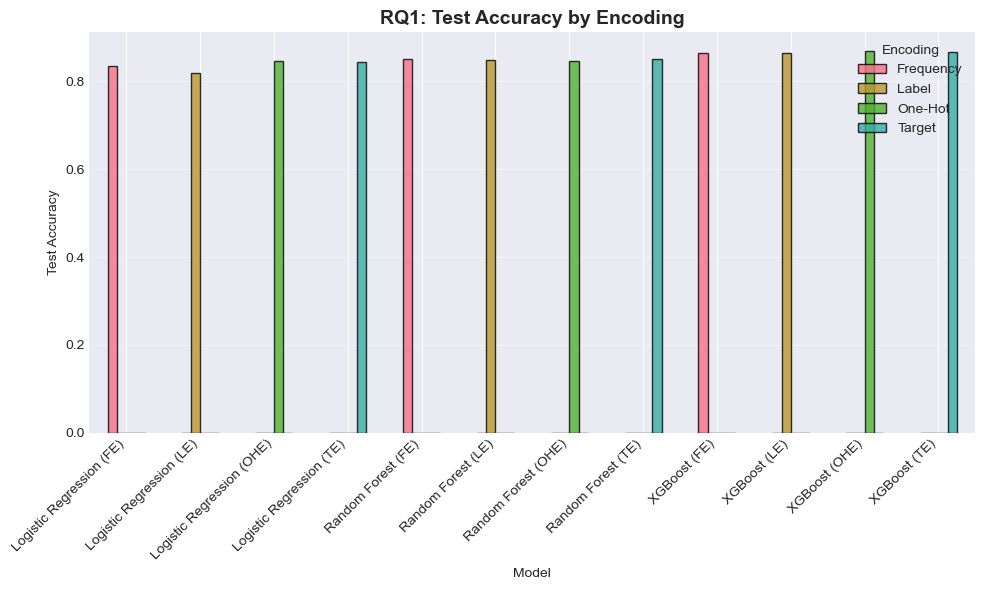

In [272]:
results_df = pd.DataFrame(all_results)
display(results_df)
encoding_summary = results_df.groupby('Encoding')[['Test Accuracy', 'F1-Score', 'AUC-ROC']].mean().sort_values('Test Accuracy', ascending=False)
print("Average by encoding:"); display(encoding_summary)

# Encoding dimensionality (RQ1: accuracy vs feature explosion)
encoding_dims = pd.DataFrame({
    'Encoding': ['One-Hot', 'Ordinal', 'Frequency'],
    'N_features': [X_train_ohe_final.shape[1], X_train_le_final.shape[1], X_train_fe_final.shape[1]]
})
print("Features per encoding:"); display(encoding_dims)

fig, ax = plt.subplots(figsize=(10, 6))
results_df.pivot_table(values='Test Accuracy', index='Model', columns='Encoding', aggfunc='first').plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
ax.set_title('RQ1: Test Accuracy by Encoding', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy'); ax.legend(title='Encoding'); ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('08_RQ1_encoding_comparison.png', dpi=300, bbox_inches='tight'); plt.show()

**Stratified 5-fold CV** with Logistic Regression (mean ± std)

In [273]:
# Cross-Validation: One-Hot vs Ordinal vs Frequency (LR only, 5-fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=1000, random_state=42)
cv_results = []

for enc_name, X_tr, X_te in [
    ("One-Hot", X_train_ohe_final, X_test_ohe_final),
    ("Ordinal", X_train_le_final, X_test_le_final),
    ("Frequency", X_train_fe_final, X_test_fe_final),
]:
    accs, f1s, rocs = [], [], []
    for train_idx, val_idx in skf.split(X_tr, y_train):
        X_fold_tr, X_fold_val = X_tr[train_idx], X_tr[val_idx]
        y_fold_tr, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        clf.fit(X_fold_tr, y_fold_tr)
        pred = clf.predict(X_fold_val)
        accs.append(accuracy_score(y_fold_val, pred))
        f1s.append(f1_score(y_fold_val, pred, zero_division=0))
        try:
            rocs.append(roc_auc_score(y_fold_val, clf.predict_proba(X_fold_val)[:, 1]))
        except Exception:
            rocs.append(np.nan)
    cv_results.append({
        "Encoding": enc_name,
        "Accuracy": f"{np.mean(accs):.4f} ± {np.std(accs):.4f}",
        "F1-Score": f"{np.mean(f1s):.4f} ± {np.std(f1s):.4f}",
        "ROC-AUC": f"{np.nanmean(rocs):.4f} ± {np.nanstd(rocs):.4f}",
    })

cv_table = pd.DataFrame(cv_results)
display(cv_table)

,Encoding,Accuracy,F1-Score,ROC-AUC
0,One-Hot,0.8486 ± 0.0033,0.6662 ± 0.0066,0.9048 ± 0.0037
1,Ordinal,0.8205 ± 0.0056,0.5611 ± 0.0143,0.8524 ± 0.0056
2,Frequency,0.8342 ± 0.0044,0.6155 ± 0.0118,0.8815 ± 0.0049


**4. Model Training**

- Train: Logistic Regression, Random Forest, Gradient Boosting (XGBoost)
- Simple train/test split
- Metrics: Accuracy, Precision, Recall, F1, ROC-AUC

*(Models already trained above per encoding; best encoding used for final comparison.)*

**5. Model Optimisation**

- RandomizedSearchCV on best model (Random Forest)
- Before vs after performance table

In [274]:
# Hyperparameter tuning: Random Forest (best model from RQ1)
from scipy.stats import randint, uniform

# Baseline (already trained)
baseline_acc = results_rf_le["Test Accuracy"]
baseline_f1 = results_rf_le["F1-Score"]
baseline_auc = results_rf_le["AUC-ROC"]

param_dist = {
    "n_estimators": randint(50, 200),
    "max_depth": randint(5, 25),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
}
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist, n_iter=20, cv=3, scoring="f1", random_state=42, n_jobs=-1
)
search.fit(X_train_le_final, y_train)
rf_tuned = search.best_estimator_
pred_tuned = rf_tuned.predict(X_test_le_final)

tuned_acc = accuracy_score(y_test, pred_tuned)
tuned_f1 = f1_score(y_test, pred_tuned, zero_division=0)
tuned_auc = roc_auc_score(y_test, rf_tuned.predict_proba(X_test_le_final)[:, 1])

tuning_table = pd.DataFrame({
    "Model": ["Random Forest (default)", "Random Forest (tuned)"],
    "Accuracy": [baseline_acc, tuned_acc],
    "F1-Score": [baseline_f1, tuned_f1],
    "ROC-AUC": [baseline_auc, tuned_auc],
})
display(tuning_table)
print("Best params:", search.best_params_)

,Model,Accuracy,F1-Score,ROC-AUC
0,Random Forest (default),0.849602,0.667352,0.903298
1,Random Forest (tuned),0.857703,0.678662,0.913610


Best params: {'max_depth': 22, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n_estimators': 63}


**6. Explainability (RQ2)**

- SHAP global feature importance
- Mean |SHAP| by group (sex)
- Short explanation: which features drive prediction and how this can relate to income inequality

In [275]:
# RQ2 Step 1: Setup
feature_names = list(numerical_features) + list(categorical_features)
SHAP_AVAILABLE = shap is not None
print("SHAP available:", SHAP_AVAILABLE)

SHAP available: True


**SHAP on best model** (Random Forest)

Using Random Forest (Label Encoding) for SHAP. Test Accuracy: 0.8496


,Feature,Mean |SHAP|
7,education,0.075456
4,capital-loss,0.066604
5,hours-per-week,0.063225
10,relationship,0.054984
0,age,0.053799
12,sex,0.035954
6,workclass,0.027828
3,capital-gain,0.016959
11,race,0.016504
9,occupation,0.015669


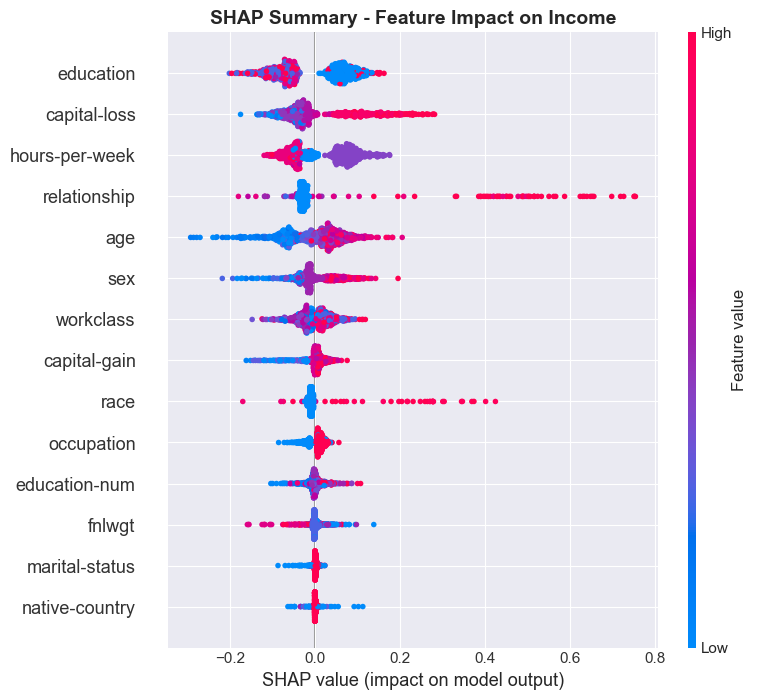

In [276]:
if SHAP_AVAILABLE:
    print("Using Random Forest (Label Encoding) for SHAP. Test Accuracy:", f"{results_rf_le['Test Accuracy']:.4f}")
    sample_size = min(1000, len(X_test_le_final))
    X_sample = X_test_le_final[:sample_size]
    explainer = shap.TreeExplainer(rf_le)
    shap_values = explainer.shap_values(X_sample)
    shap_values_pos = shap_values[1] if isinstance(shap_values, list) else (shap_values[:, :, 1] if hasattr(shap_values, 'ndim') and shap_values.ndim == 3 else shap_values)
    mean_shap = np.abs(shap_values_pos).mean(axis=0)
    importance_df = pd.DataFrame({'Feature': feature_names, 'Mean |SHAP|': mean_shap}).sort_values('Mean |SHAP|', ascending=False)
    display(importance_df)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_pos, X_sample, feature_names=feature_names, show=False)
    plt.title('SHAP Summary - Feature Impact on Income', fontsize=14, fontweight='bold'); plt.tight_layout()
    plt.savefig('10_RQ2_shap_summary.png', dpi=300, bbox_inches='tight'); plt.show()

**Mean |SHAP| by group (sex)** — which features matter per group; differences can reflect inequality in how the model uses inputs.

In [277]:
# Mean |SHAP| by group (sex) — extends SHAP analysis for RQ2 / inequality
if SHAP_AVAILABLE and rf_le is not None:
    sample_size = min(500, len(X_test_le_final))
    X_sample = X_test_le_final[:sample_size]
    sex_sample = df_test_clean["sex"].iloc[:sample_size].values
    explainer_grp = shap.TreeExplainer(rf_le)
    sv = explainer_grp.shap_values(X_sample)
    sv_pos = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if hasattr(sv, "ndim") and sv.ndim == 3 else sv)
    abs_sv = np.abs(sv_pos)  # (n_sample, n_features)

    by_sex = []
    for g in np.unique(sex_sample):
        mask = (sex_sample == g)
        mean_abs = abs_sv[mask].mean(axis=0)
        by_sex.append(pd.DataFrame({"Feature": feature_names, "Mean |SHAP|": mean_abs, "Group": g}))
    shap_by_sex_df = pd.concat(by_sex, ignore_index=True)
    pivot_shap = shap_by_sex_df.pivot_table(values="Mean |SHAP|", index="Feature", columns="Group")
    pivot_shap = pivot_shap.reindex(pivot_shap.max(axis=1).sort_values(ascending=False).index)
    display(pivot_shap.head(12))
else:
    print("SHAP or rf_le not available; skipping explainability by group.")

Group,Female,Male
Feature,,
education,0.084955,0.071800
capital-loss,0.054242,0.071556
hours-per-week,0.057771,0.064895
relationship,0.032811,0.062972
age,0.045970,0.058673
sex,0.030897,0.037145
workclass,0.020976,0.030777
occupation,0.021389,0.013203
capital-gain,0.009620,0.019504


**Feature importance fallback** (if SHAP not installed)

In [278]:
if not SHAP_AVAILABLE:
    importances = rf_le.feature_importances_
    indices = np.argsort(importances)[::-1]
    top_n = 15
    for i in range(min(top_n, len(feature_names))):
        print(f"  {feature_names[indices[i]]:20s}: {importances[indices[i]]:.4f}")
    plt.figure(figsize=(12, 8))
    plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue', edgecolor='black', alpha=0.8)
    plt.yticks(range(top_n), [feature_names[indices[i]] for i in range(top_n-1, -1, -1)])
    plt.xlabel('Feature Importance'); plt.title('RQ2: Top 15 Feature Importances'); plt.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.savefig('09_RQ2_feature_importance.png', dpi=300, bbox_inches='tight'); plt.show()

**7. Fairness Analysis (RQ3)**

- Train with all features vs without sensitive features (sex, race)
- Compare: Accuracy | F1 | Selection Rate Disparity | TPR Disparity
- Trade-off: dropping sensitive features can slightly change accuracy but improves fairness; use non-sensitive model when fairness is a priority.

In [279]:
# RQ3 Step 1: Build data without sex and race
sensitive_features = ['sex', 'race']
non_sensitive_categorical = [f for f in categorical_features if f not in sensitive_features]
features_ns = numerical_features + non_sensitive_categorical

X_train_ns = X_train[features_ns].copy()
X_test_ns = X_test[features_ns].copy()
for feat in non_sensitive_categorical:
    le = LabelEncoder()
    X_train_ns[feat] = le.fit_transform(X_train_ns[feat].astype(str))
    X_test_ns[feat] = X_test_ns[feat].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

scaler_ns = StandardScaler()
X_train_ns_final = scaler_ns.fit_transform(X_train_ns.values.astype(np.float64))
X_test_ns_final = scaler_ns.transform(X_test_ns.values.astype(np.float64))
print("Non-sensitive features:", features_ns)

Non-sensitive features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']


**Train models without sex and race**

In [280]:
fairness_results = []
# Non-sensitive models
for name, model in [("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
                    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))]:
    res = evaluate_model(model, X_train_ns_final, y_train, X_test_ns_final, y_test, name)
    res['Feature Set'] = 'Non-Sensitive'
    fairness_results.append(res)
if xgb is not None:
    res = evaluate_model(xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss'),
                         X_train_ns_final, y_train, X_test_ns_final, y_test, "XGBoost")
    res['Feature Set'] = 'Non-Sensitive'
    fairness_results.append(res)

**Add full-feature results and compare**

In [281]:
# Full feature set (from RQ1 Label Encoding)
for res_le, base_name in [(results_lr_le, "Logistic Regression"), (results_rf_le, "Random Forest")]:
    r = res_le.copy()
    r['Feature Set'] = 'Full (with Sensitive)'
    r['Model'] = base_name
    fairness_results.append(r)
if xgb is not None:
    r = results_xgb_le.copy()
    r['Feature Set'] = 'Full (with Sensitive)'
    r['Model'] = 'XGBoost'
    fairness_results.append(r)

fairness_df = pd.DataFrame(fairness_results)
fairness_df['Model Base'] = fairness_df['Model'].str.replace(' (LE)', '', regex=False)
display(fairness_df[['Model', 'Feature Set', 'Test Accuracy', 'F1-Score', 'AUC-ROC']])

,Model,Feature Set,Test Accuracy,F1-Score,AUC-ROC
0,Logistic Regression,Non-Sensitive,0.817663,0.546715,0.843189
1,Random Forest,Non-Sensitive,0.851328,0.673282,0.902526
2,XGBoost,Non-Sensitive,0.866534,0.708864,0.924406
3,Logistic Regression,Full (with Sensitive),0.820252,0.555720,0.848296
4,Random Forest,Full (with Sensitive),0.849602,0.667352,0.903298
5,XGBoost,Full (with Sensitive),0.865471,0.707056,0.924415


**Group-wise selection rate and TPR** (sex, race); disparity summary table: Full vs Non-sensitive

In [282]:
# Group-wise fairness: selection rate and TPR (sex, race)
def selection_rate(y_true, y_pred):
    return (y_pred == 1).mean()
def tpr(y_true, y_pred):
    pos = (y_true == 1)
    if pos.sum() == 0:
        return np.nan
    return (y_pred[pos] == 1).mean()

# Predictions: full model (rf_le) and non-sensitive model
pred_full = rf_le.predict(X_test_le_final)
rf_ns = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_ns.fit(X_train_ns_final, y_train)
pred_ns = rf_ns.predict(X_test_ns_final)

test_df = df_test_clean.reset_index(drop=True)
groups = {"sex": test_df["sex"], "race": test_df["race"]}

def group_metrics(y_true, y_pred, group_series, name):
    rows = []
    for g in group_series.dropna().unique():
        mask = (group_series == g).values
        if mask.sum() == 0:
            continue
        yt, yp = y_true[mask], y_pred[mask]
        rows.append({"Group": f"{name}={g}", "Selection rate": selection_rate(yt, yp), "TPR": tpr(yt, yp)})
    return pd.DataFrame(rows)

# Group-wise tables
print("Full model (rf_le) — by sex and race:")
for attr, series in groups.items():
    dm = group_metrics(y_test.values, pred_full, series, attr)
    if len(dm) > 0:
        display(dm)
        sr_diff = dm["Selection rate"].max() - dm["Selection rate"].min()
        tpr_diff = dm["TPR"].max() - dm["TPR"].min()
        print(f"  Selection-rate range: {sr_diff:.4f}; TPR range: {tpr_diff:.4f}")

print("\nNon-sensitive model — by sex and race:")
for attr, series in groups.items():
    dm = group_metrics(y_test.values, pred_ns, series, attr)
    if len(dm) > 0:
        display(dm)
        sr_diff = dm["Selection rate"].max() - dm["Selection rate"].min()
        tpr_diff = dm["TPR"].max() - dm["TPR"].min()
        print(f"  Selection-rate range: {sr_diff:.4f}; TPR range: {tpr_diff:.4f}")

# Fairness comparison: Full vs Non-sensitive
def disparity_sr_tpr(y_true, y_pred, group_series):
    df = group_metrics(y_true, y_pred, group_series, "attr")
    if len(df) < 2:
        return np.nan, np.nan
    return df["Selection rate"].max() - df["Selection rate"].min(), df["TPR"].max() - df["TPR"].min()

sr_full_sex, tpr_full_sex = disparity_sr_tpr(y_test.values, pred_full, test_df["sex"])
sr_ns_sex, tpr_ns_sex = disparity_sr_tpr(y_test.values, pred_ns, test_df["sex"])
sr_full_race, tpr_full_race = disparity_sr_tpr(y_test.values, pred_full, test_df["race"])
sr_ns_race, tpr_ns_race = disparity_sr_tpr(y_test.values, pred_ns, test_df["race"])

fairness_compare = pd.DataFrame([
    {
        "Model": "Full (with sensitive)",
        "Accuracy": accuracy_score(y_test, pred_full),
        "F1": f1_score(y_test, pred_full, zero_division=0),
        "Selection-rate diff (sex)": sr_full_sex,
        "TPR diff (sex)": tpr_full_sex,
    },
    {
        "Model": "Non-sensitive",
        "Accuracy": accuracy_score(y_test, pred_ns),
        "F1": f1_score(y_test, pred_ns, zero_division=0),
        "Selection-rate diff (sex)": sr_ns_sex,
        "TPR diff (sex)": tpr_ns_sex,
    },
])
display(fairness_compare)

# Fairness disparity summary: Full vs Non-sensitive (by sex and race)
disparity_summary = pd.DataFrame([
    {"Model": "Full (with sensitive)", "Selection Rate Disparity (sex)": sr_full_sex, "Selection Rate Disparity (race)": sr_full_race, "TPR Disparity (sex)": tpr_full_sex, "TPR Disparity (race)": tpr_full_race},
    {"Model": "Non-sensitive", "Selection Rate Disparity (sex)": sr_ns_sex, "Selection Rate Disparity (race)": sr_ns_race, "TPR Disparity (sex)": tpr_ns_sex, "TPR Disparity (race)": tpr_ns_race},
])
print("Fairness disparity summary (max − min by group):"); display(disparity_summary)

Full model (rf_le) — by sex and race:


,Group,Selection rate,TPR
0,sex=Male,0.264512,0.622654
1,sex=Female,0.086505,0.565530


  Selection-rate range: 0.1780; TPR range: 0.0571


,Group,Selection rate,TPR
0,race=Black,0.087881,0.577381
1,race=White,0.220971,0.618468
2,race=Other,0.090164,0.416667
3,race=Amer-Indian-Eskimo,0.060403,0.368421
4,race=Asian-Pac-Islander,0.242647,0.619835


  Selection-rate range: 0.1822; TPR range: 0.2514

Non-sensitive model — by sex and race:


...

,Group,Selection rate,TPR
0,race=Black,0.098512,0.601190
1,race=White,0.221126,0.623515
2,race=Other,0.106557,0.500000
3,race=Amer-Indian-Eskimo,0.134228,0.684211
4,race=Asian-Pac-Islander,0.276961,0.669421


  Selection-rate range: 0.1784; TPR range: 0.1842


,Model,Accuracy,F1,Selection-rate diff (sex),TPR diff (sex)
0,Full (with sensitive),0.849602,0.667352,0.178006,0.057124
1,Non-sensitive,0.851328,0.673282,0.178416,0.057692


Fairness disparity summary (max − min by group):


,Model,Selection Rate Disparity (sex),Selection Rate Disparity (race),TPR Disparity (sex),TPR Disparity (race)
0,Full (with sensitive),0.178006,0.182244,0.057124,0.251414
1,Non-sensitive,0.178416,0.178449,0.057692,0.184211


**Accuracy impact: Full vs Non-sensitive** (plot)

Logistic Regression: Full=0.8203, Non-Sensitive=0.8177, Drop=0.0026
Random Forest: Full=0.8496, Non-Sensitive=0.8513, Drop=-0.0017
XGBoost: Full=0.8655, Non-Sensitive=0.8665, Drop=-0.0011


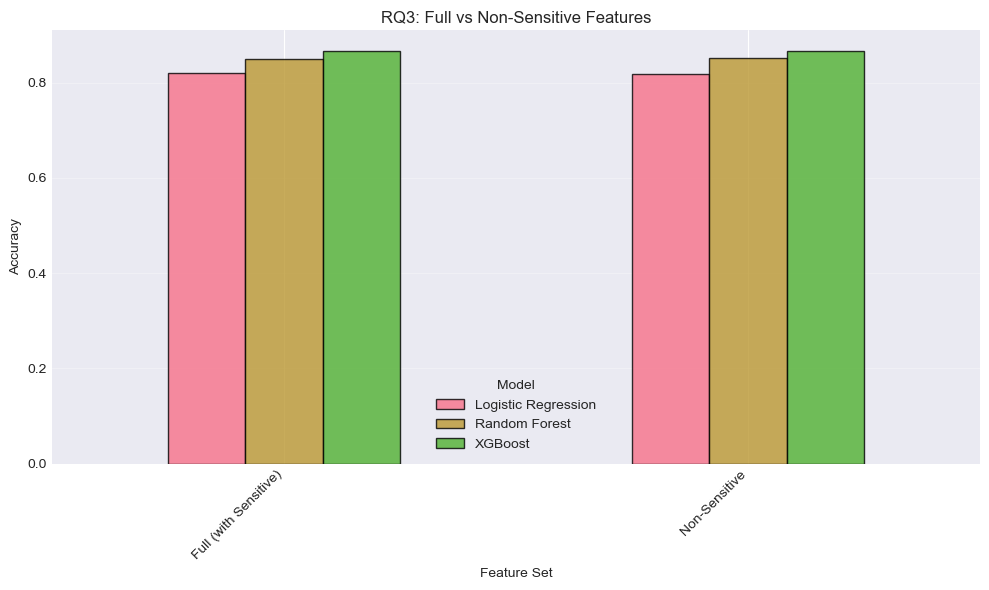

In [283]:
for model_name in fairness_df['Model Base'].unique():
    full_row = fairness_df[(fairness_df['Model Base'] == model_name) & (fairness_df['Feature Set'] == 'Full (with Sensitive)')]
    ns_row = fairness_df[(fairness_df['Model Base'] == model_name) & (fairness_df['Feature Set'] == 'Non-Sensitive')]
    if len(full_row) and len(ns_row):
        full_acc = full_row['Test Accuracy'].values[0]
        ns_acc = ns_row['Test Accuracy'].values[0]
        print(f"{model_name}: Full={full_acc:.4f}, Non-Sensitive={ns_acc:.4f}, Drop={full_acc - ns_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
pivot = fairness_df.pivot_table(values='Test Accuracy', index='Feature Set', columns='Model Base', aggfunc='first')
pivot.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
ax.set_title('RQ3: Full vs Non-Sensitive Features'); ax.set_ylabel('Accuracy')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right'); ax.legend(title='Model'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('13_RQ3_fairness_comparison.png', dpi=300, bbox_inches='tight'); plt.show()

**8. Final Evaluation**

- Confusion matrix for final model (tuned RF or default RF)
- ROC curve
- Final model selection: best performer from optimisation step

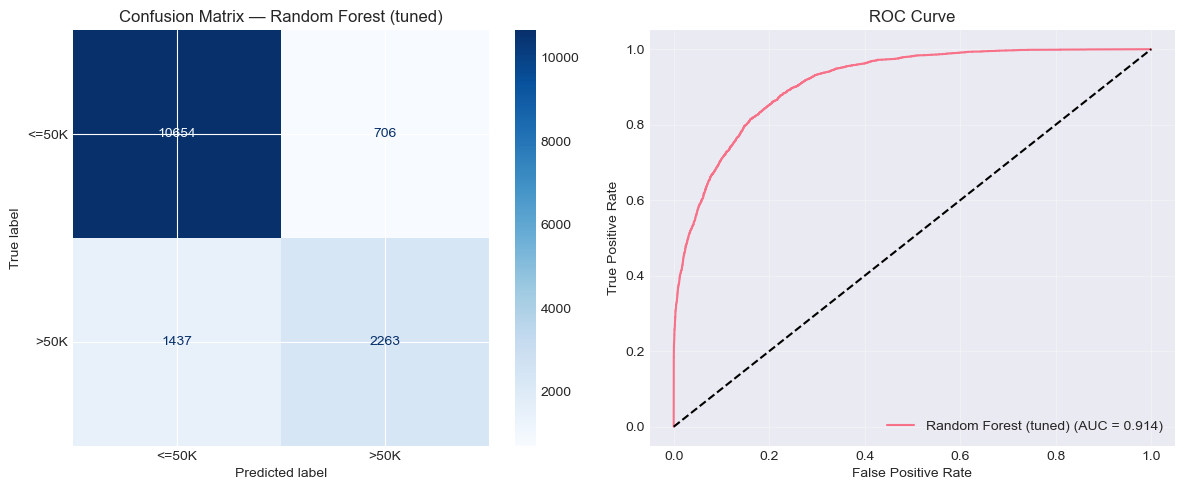

In [284]:
# Final model: use tuned RF if available, else default RF (same random_state for reproducibility)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

try:
    final_model = rf_tuned
    final_name = "Random Forest (tuned)"
except NameError:
    final_model = rf_le
    final_name = "Random Forest (LE)"
y_pred_final = final_model.predict(X_test_le_final)
y_proba_final = final_model.predict_proba(X_test_le_final)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
disp.plot(ax=axes[0], cmap="Blues", values_format="d")
axes[0].set_title(f"Confusion Matrix — {final_name}")

# ROC curve
fpr, tpr_roc, _ = roc_curve(y_test, y_proba_final)
axes[1].plot(fpr, tpr_roc, label=f"{final_name} (AUC = {roc_auc_score(y_test, y_proba_final):.3f})")
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("final_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

**9. Conclusions**

- RQ1: Best encoding and mean test accuracy (from computed results)
- RQ2: Key drivers from SHAP/importance
- RQ3: Accuracy trade-off when removing sensitive features (from computed results)
- No hard-coded numbers; all values from this run

In [285]:
# Dynamic conclusions (from computed results)
best_enc = encoding_summary.index[0]
best_acc = encoding_summary.loc[best_enc, 'Test Accuracy']
print("RQ1 — Best encoding:", best_enc, f"(mean test accuracy: {best_acc:.4f})")
print("RQ2 — Key drivers: see SHAP/importance plot (e.g. education, occupation, age, hours-per-week)")
rf_full = fairness_df[(fairness_df['Model Base'] == 'Random Forest') & (fairness_df['Feature Set'] == 'Full (with Sensitive)')]['Test Accuracy'].values
rf_ns = fairness_df[(fairness_df['Model Base'] == 'Random Forest') & (fairness_df['Feature Set'] == 'Non-Sensitive')]['Test Accuracy'].values
rf_drop = (rf_full - rf_ns)[0] if len(rf_full) and len(rf_ns) else 0
print(f"RQ3 — Non-sensitive vs full: Random Forest accuracy drop = {rf_drop:.4f}; use non-sensitive for fairness-sensitive applications.")

RQ1 — Best encoding: One-Hot (mean test accuracy: 0.8541)
RQ2 — Key drivers: see SHAP/importance plot (e.g. education, occupation, age, hours-per-week)
RQ3 — Non-sensitive vs full: Random Forest accuracy drop = -0.0017; use non-sensitive for fairness-sensitive applications.


**10. Academic Declaration**

- AI tools (e.g. for code or text) may have been used during this project in line with module guidelines.
- The student is responsible for understanding and being able to explain all submitted work and for the correctness of results and conclusions.